# **[W4] Pilot Task_Final**



## **데이터 기본 정보**

**<데이터 개요>**
- 사용 데이터: **Kaggle: Predict Customer Churn**

- URL: https://www.kaggle.com/competitions/playground-series-s6e3/overview

- 목표: 고객 이탈 가능성 예측

- 평가 지표: ROC

---

**<분석 목적>**
- 분석 목적: 통신사 고객 이탈 여부(`churn`)에 영향을 미치는 주요 요인을 파악하고, 이를 기반으로 고객 유지를 위한 인사이트를 도출

- 기대 인사이트
    - 어떤 계약 형태(`Contract`)가 고객 유지에 유리한가?
    - 가입 기간(`Tenure`)과 이탈률 사이에는 어떤 상관관계가 있는가
    - 월 요금의 수준(`MonthlyCharges`)이 고객 이탈의 결정적 요인인가?
    
---

**<데이터 구성>**
- train.csv: 학습용 데이터, 594,194행
- test.csv: 평가용 데이터, 254,651행
- sample_submission.csv: 제출 예시.(본 분석에서는 필요하지 않음)

## **기본 설정**

In [ ]:
# pip install
!pip install optuna

In [ ]:
# 기본 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import optuna.visualization as vis

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 모델
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, classification_report

In [ ]:
# Kaggle setting
from google.colab import userdata
import os
import kagglehub

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

path = kagglehub.competition_download('playground-series-s6e3')

print("Path to dataset files", path)

print("Files in path:", os.listdir(path))


100%|██████████| 14.9M/14.9M [00:00<00:00, 153MB/s]

Extracting files...


Path to dataset files /root/.cache/kagglehub/competitions/playground-series-s6e3
Files in path: ['train.csv', 'sample_submission.csv', 'test.csv']


In [ ]:
# (기본) 데이터 불러오기
train = pd.read_csv(path + '/train.csv')
test = pd.read_csv(path + '/test.csv')
submission = pd.read_csv(path + '/sample_submission.csv')

In [ ]:
# 복사본 생성
train_df = train.copy()
test_df = test.copy()

## **[W1] EDA**

### **기초 통계 확인**
**<기초 통계>**
- 데이터 규모: train (594194, 21) | test(254655, 20)
- 결측치: 없음(0건)
- 데이터 특징: float64(2), int64(3), object(16)

---
**<변수 설명>**
1. 고객 기본 정보
- `id`: 고객 식별 번호
- `gender`: 성별 (Male, Female)
- `SeniorCitizen`: 고령자 여부 (1: 고령자, 0: 일반)
- `Partner`: 배우자(파트너) 여부 (Yes, No)
- `Dependents`: 부양가족(자녀, 부모 등) 여부 (Yes, No)

2.서비스 가입 현황

- `tenure`: 서비스 이용한 기간 (개월 수)
- `PhoneService`: 전화 서비스 사용 여부 (Yes, No)
- `MultipleLines`: 다회선 사용 여부 (Yes, No, No phone service)
- `InternetService`: 인터넷 서비스 제공업체 종류 (DSL, Fiber optic, No)
- `OnlineSecurity`: 온라인 보안 서비스 사용 여부 (Yes, No, No internet service)
- `OnlineBackup`: 온라인 백업 서비스 사용 여부 (Yes, No, No internet service)
- `DeviceProtection`: 기기 보호 서비스 사용 여부 (Yes, No, No internet service)
- `TechSupport`: 기술 지원 서비스 사용 여부 (Yes, No, No internet service)
- `StreamingTV`: TV 스트리밍 서비스 사용 여부 (Yes, No, No internet service)
- `StreamingMovies`: 영화 스트리밍 서비스 사용 여부 (Yes, No, No internet service)

3. 계약 및 결제 정보

- `Contract`: 계약 형태 (Month-to-month: 월 단위, One year: 1년, Two year: 2년)
- `PaperlessBilling`: 종이 없는 청구서(전자 청구서) 사용 여부 (Yes, No)
- `PaymentMethod`: 결제 수단(Electronic check: 인라인 코드(전자 수표)| Mailed check: 우편 수표 | Bank transfer(automatic): 자동 은행 이체 | Credit card (automatic): 자동 신용카드 결제)
- `MonthlyCharges`: 매달 청구되는 금액
- `TotalCharges`: 현재까지 청구된 총 금액

4. 타겟 변수 (Target Variable)
- `Churn`: 고객의 이탈 여부 (Yes: 이탈함, No: 유지 중) - 분석의 핵심 목표 변수입니다.

In [ ]:
# 데이터 형태
train.head(10)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
5,5,Male,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),20.20,20.20,No
6,6,Female,0,Yes,Yes,24,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,533.60,No
7,7,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Electronic check,92.00,6827.50,No
8,8,Female,1,No,No,1,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,79.55,79.55,Yes
9,9,Male,0,No,No,55,Yes,No,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.05,4738.30,No


In [ ]:
# 데이터 규모
print(f"train: {train.shape}")
print(f"test: {test.shape}")

train: (594194, 21)
test: (254655, 20)


In [ ]:
# 결측지 확인
print(f"train: {train.isnull().sum()}\n")
print(f"test: {test.isnull().sum()}")

train: id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

test: id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


In [ ]:
# 데이터 특징
print(f"train: {train.info()}\n")
print(f"test: {test.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

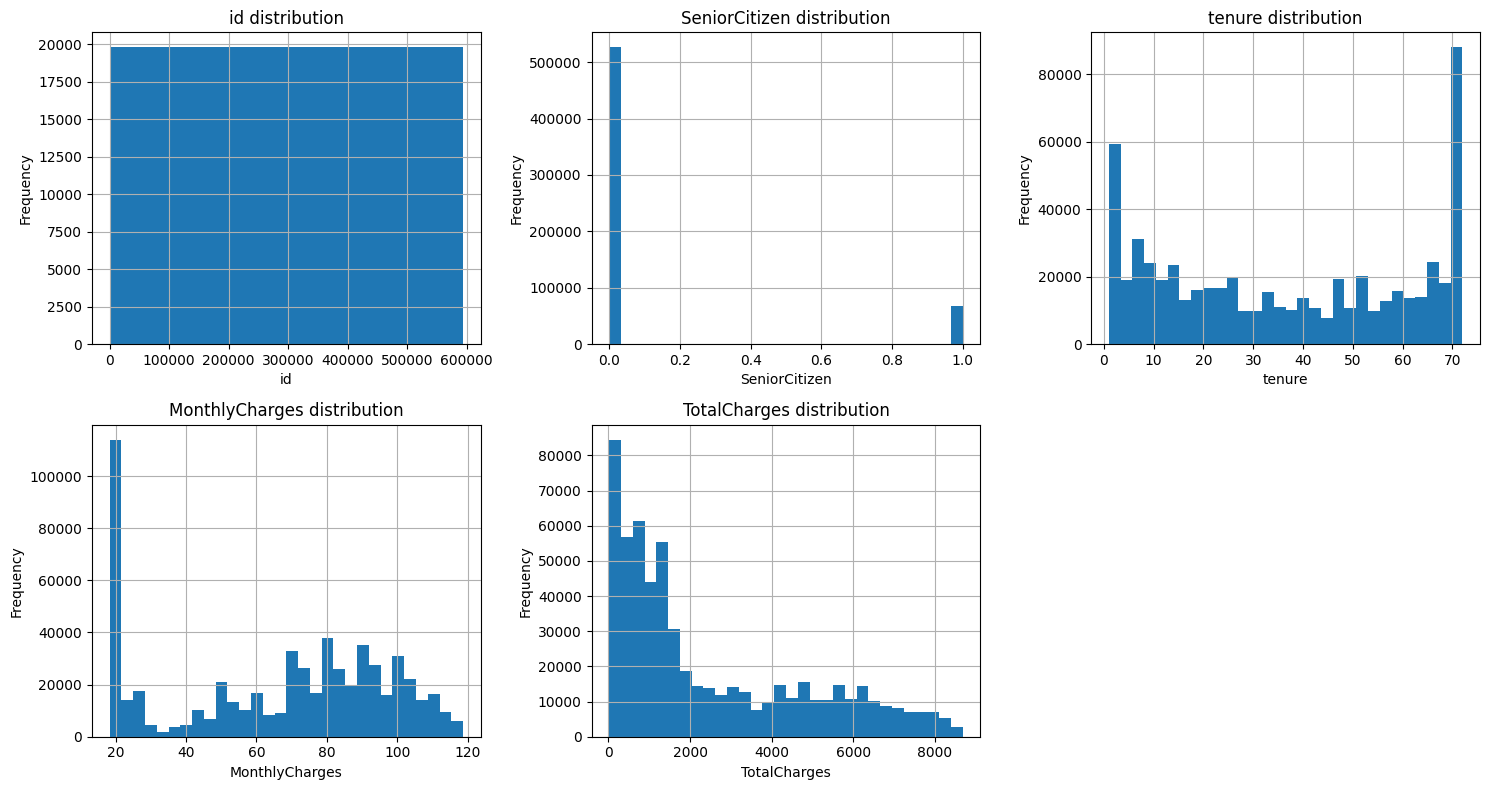

In [ ]:
# 데이터 분포 확인(숫자형)
numerical_cols = train.select_dtypes(include=np.number).columns

n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Histogram.
for i, column in enumerate(numerical_cols):
    if i < len(axes):
        train[column].hist(ax=axes[i], bins=30)
        axes[i].set_title(f"{column} distribution")
        axes[i].set_xlabel(column)
        axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

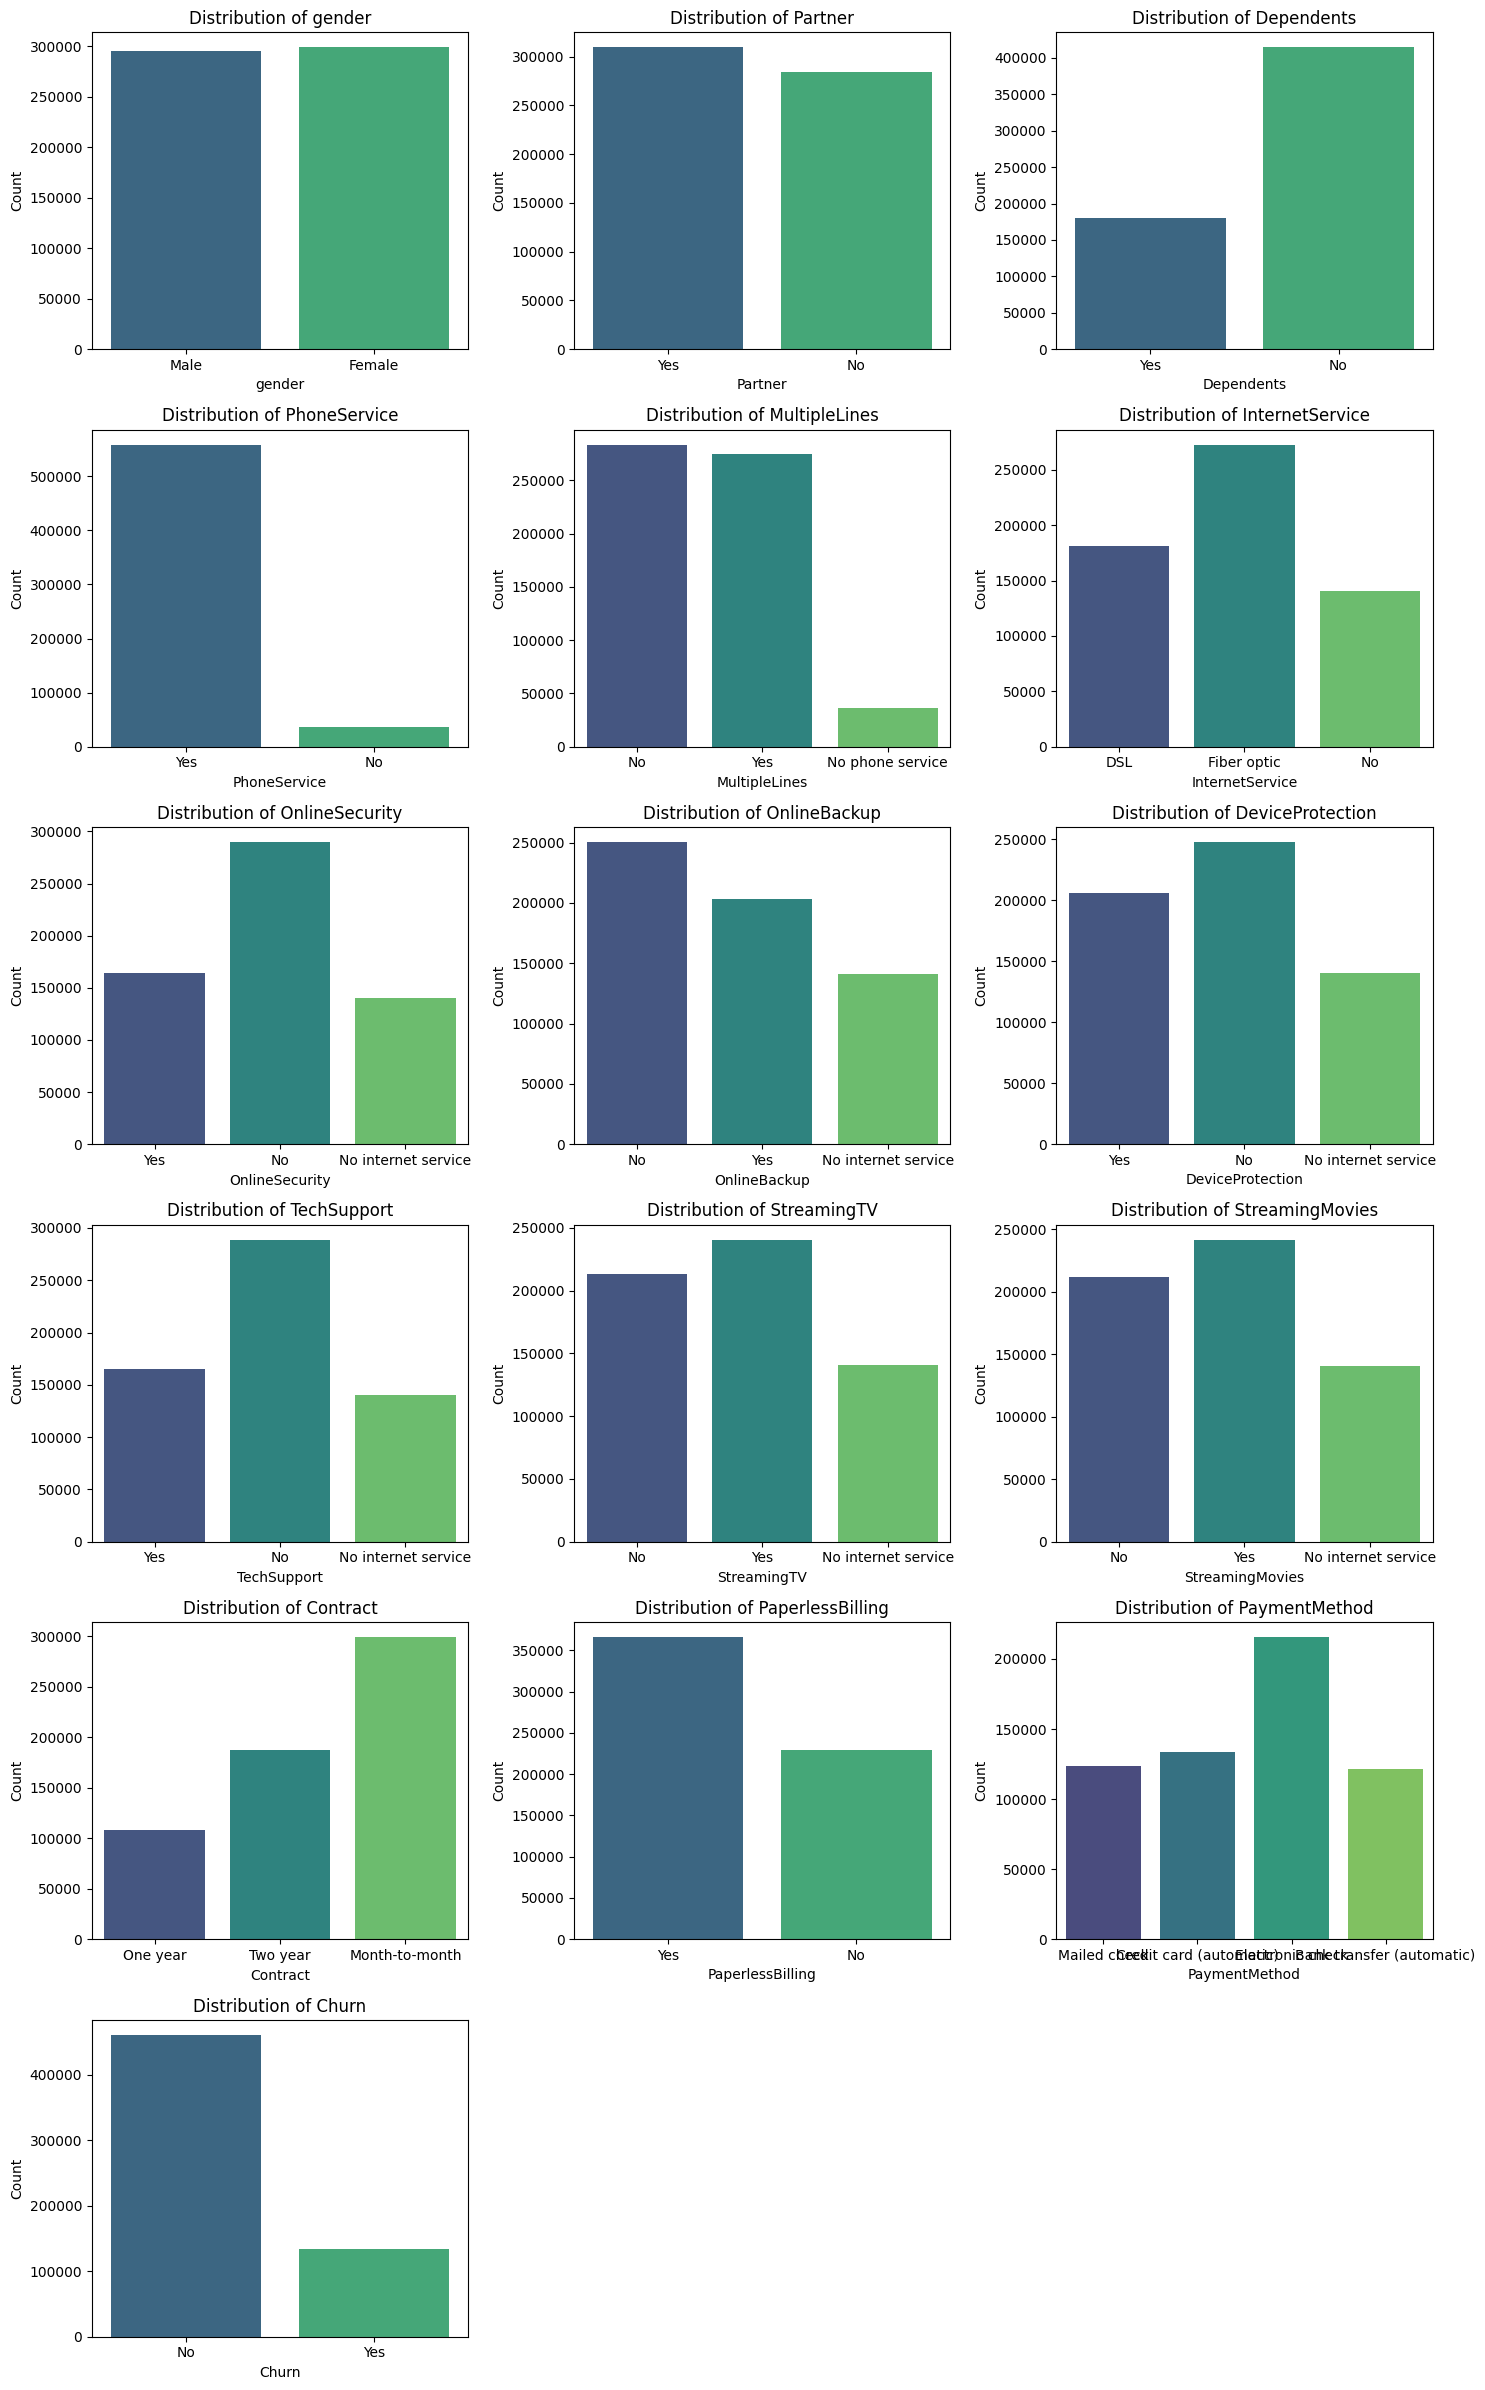

In [ ]:
# 데이터 분포 확인(범주형)
categorical_cols = train.select_dtypes(include='object').columns

n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Countplot
for i, column in enumerate(categorical_cols):
    if i < len(axes):
        sns.countplot(x=column, data=train, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribution of {column}')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Count')
        if len(train[column].unique()) > 5:
            axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### EDA

**[Plot 1] Distribution of Customer Churn**
- 전체 고객 중 이탈한 고객(Yes)과 유지 중인 고객(No)의 비율을 나타냄
- 결과: Yes(약 25.5%), No(약 75.5%)
- 해석: 전체 고객 중 이탈 고객이 1/4를 차지하고 있음. 비즈니스 수익에 영향이 있을 것임.

**[Plot 2] Distribution of Customer Churn**
- 계약 형태(월별, 1년, 2년)에 따라 이탈자가 얼마나 발생하는지를 나타냄
- 결과: 월별(Month-to-month)에서 이탈자가 가장 많이 나타남. 반대로 장기 계약일수록 이탈자가 급격히 줄어듦
- 해석: 계약기간은 이탈의 핵심 요인이라고 볼 수 있음. 고객을 오랫동안 유치하는 것이 중요하다고 볼 수 있음

**[Plot 3] Tenure Distribution by Churn Status**
- 이탈 여부에 따른 가입 기간의 분포
- 결과: 이탈한 고객(Yes)의 경우 대개 가입한지 오래되지 않은 신규 고객이 많음. 반면, 지속적으로 이용하는 고객(No)의 경우 상자 분포가 위로 길게 뻗어 있음
- 해석: 가입 초기 단계에서 적응을 하지 못하는 경우 장기 고객으로 전환이 잘 되지 않음

**[Plot 4] Monthly Charges Density by Churn**
- 월 요금(Monthly Charges)의 액수에 따라 이탈자와 유지자의 밀집도 차이
- 결과:
    - 저가 구간(20$ 내외): 유지 고객(No, 파란색)의 밀도가 높음
    
    - 고가 구간(70~100$): 이탈 고객(Yes, 주황색)의 분포가 유지 고객보다 더욱 밀집되어 있음
- 해석: 비싼 요금이 초기 고객에게 이탈 요인으로 작용할 수 있음.

**[Plot 5] Correlation Heatmap of Numerical Features**
- 주요 상관 관계: tenure-TotalCharges(0.77) | Monthlycharges-TotalCharges(0.66) | **tenure-Churn_Encoded(-0.43)**
- 결과:
    - tenure-Churn_Encoded(-0.43): 가입기간이 늘어날수록 이탈 확률이 낮아짐

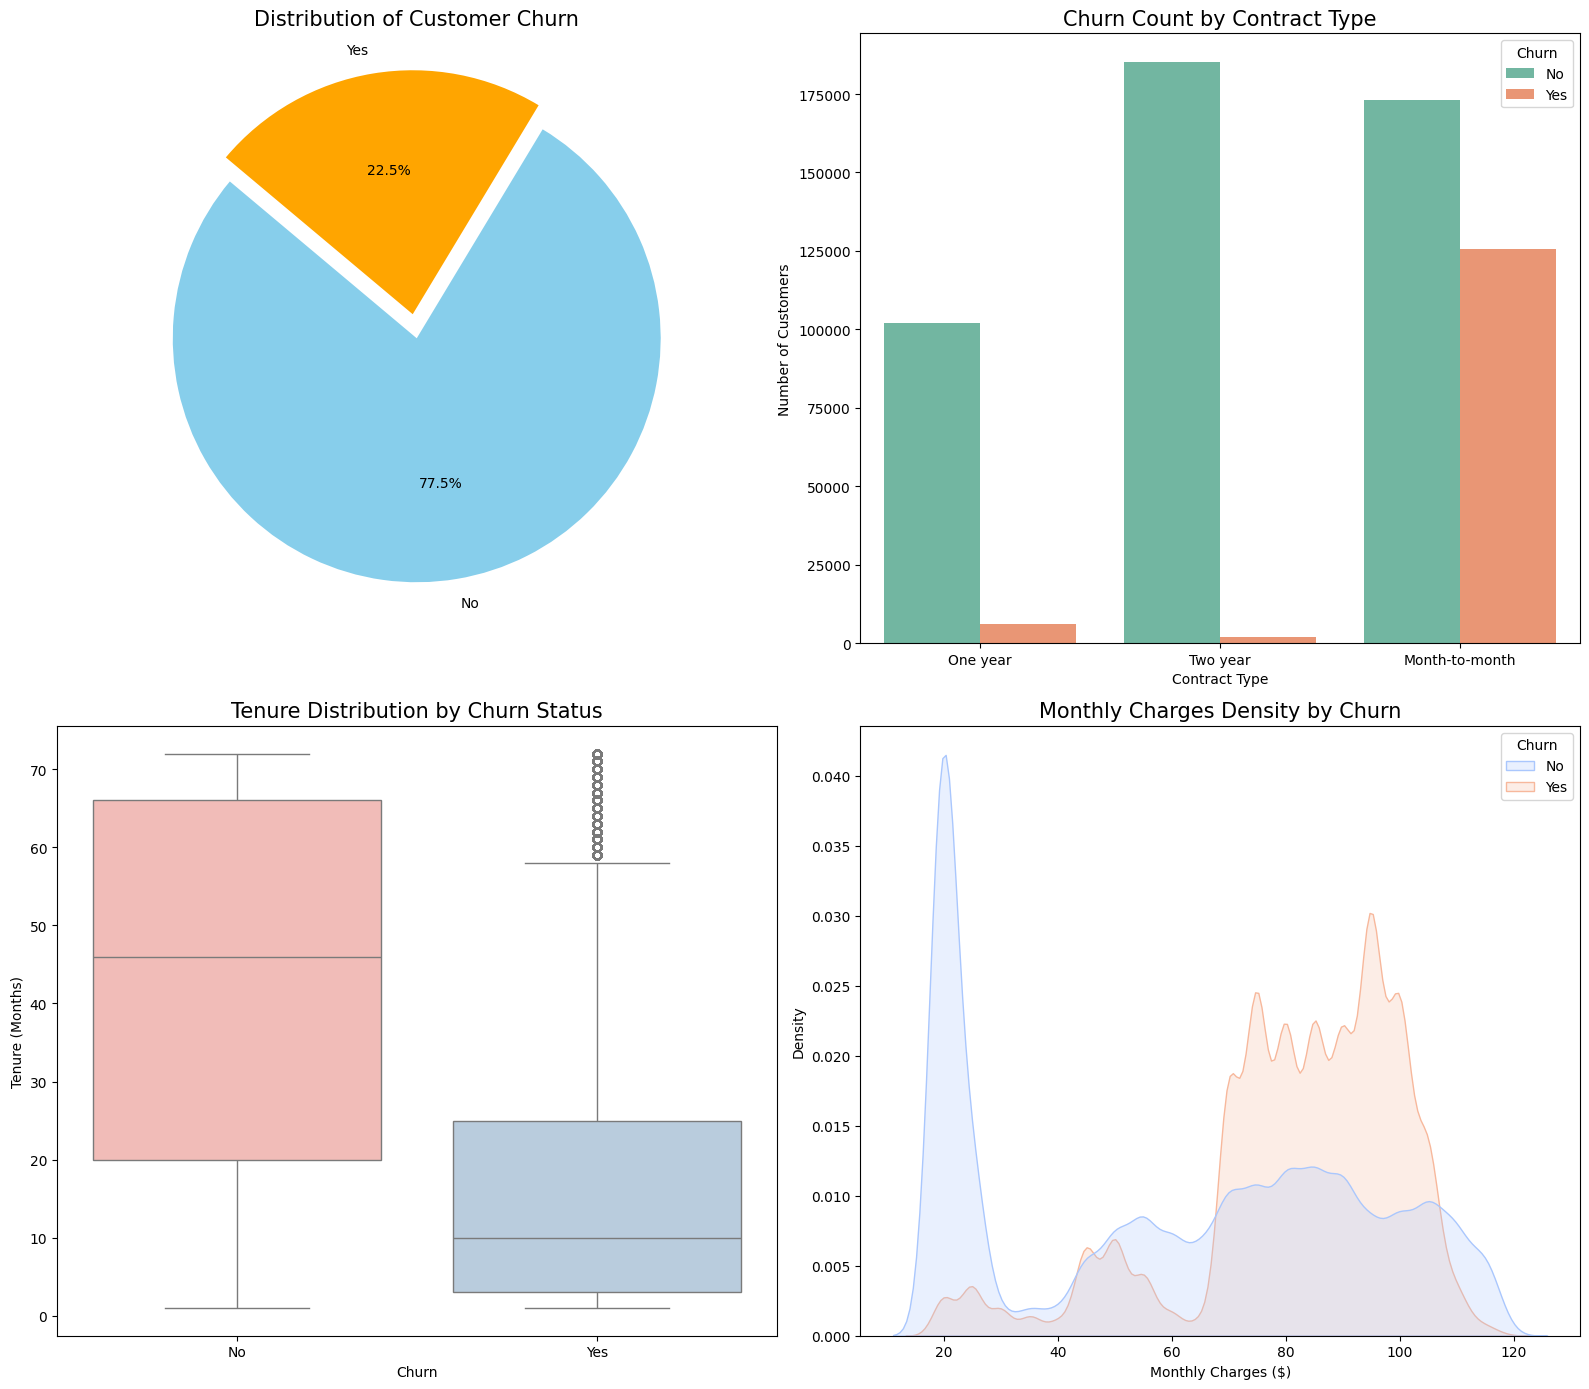

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# [Plot 1] 이탈 여부 비율 (Pie Chart)
churn_counts = train['Churn'].value_counts()
axes[0, 0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
                startangle=140, colors=['skyblue', 'orange'], explode=[0, 0.1])
axes[0, 0].set_title('Distribution of Customer Churn', fontsize=15)

# [Plot 2] 계약 형태와 이탈 관계 (Count Plot)
sns.countplot(data=train, x='Contract', hue='Churn', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Churn Count by Contract Type', fontsize=15)
axes[0, 1].set_xlabel('Contract Type')
axes[0, 1].set_ylabel('Number of Customers')

# [Plot 3] 가입 기간과 이탈 관계 (Box Plot)
sns.boxplot(data=train, x='Churn', y='tenure', palette='Pastel1', ax=axes[1, 0])
axes[1, 0].set_title('Tenure Distribution by Churn Status', fontsize=15)
axes[1, 0].set_xlabel('Churn')
axes[1, 0].set_ylabel('Tenure (Months)')

# [Plot 4] 월 요금과 이탈의 밀도 분석 (KDE Plot)
sns.kdeplot(data=train, x='MonthlyCharges', hue='Churn', fill=True,
            common_norm=False, palette='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Monthly Charges Density by Churn', fontsize=15)
axes[1, 1].set_xlabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

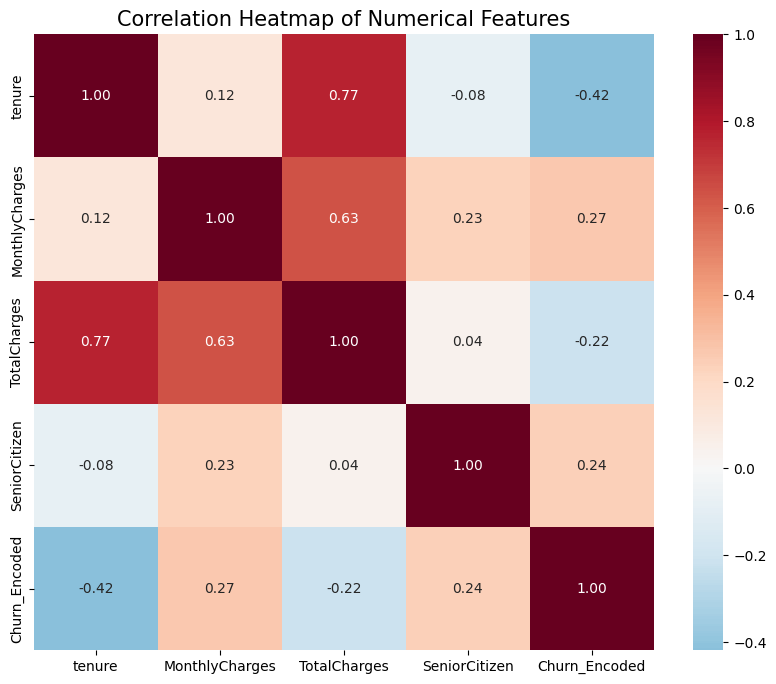

In [ ]:
# [Plot 5] 상관관계 히트맵
train['Churn_Encoded'] = train['Churn'].map({'Yes': 1, 'No': 0})

# 주요 변수 선택 및 상관계수 산출
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_Encoded']
corr_matrix = train[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features', fontsize=15)
plt.show()

## **[W2] 데이터 전처리**
1. **이상치/결측치 처리**: 이상치/결측치가 존재하지 않으므로 해당 단계 미진행

2. **데이터 전처리**
    1) **컬럼 제거**: 모델 학습에 필요하지 않은 `id` 컬럼 제거
    2) **데이터 변환**:
        - 모델 예측에 필요한 `target data`(`Churn: 고객 이탈 여부`) 분리
        - `binary data` 자료 형태 변환(object > numberic)
    3) **피처 엔지니어링**
        > 1. Feature 1(`ServiceCount`): 서비스 이용 개수  
        > 2. Feature 2(`AvgMonthlyFee`): 월 평균 청구 금액
        
        <사전 EDA 결과 및  생성 논리>
        1. 여러 서비스를 동시에 이용할 수록 다른 상품으로의 이탈이 어려워짐 > 장기 이용 고객일수록 이탈이 줄어듦

        2. 월 요금 액수가 커질수록 이탈자가 늘어나는 경향을 보임 > 월 평균 지출액을 산출하여 이를 검증( `TotalCharges(청구된 총 금액) / tenure(서비스 이용 기간)`) 월 요금 따라 이탈자와 유지자의 차이가 심함
    4) **데이터 인코딩**
        - 범주형 데이터에 대해 `One-hot Encoding`을 진행함
        - 다른 Encoding 방법은 추후 상황에 따라 적용
    5) **데이터 스케일링**
        - 대부분의 수치형 데이터는 요금, 기간을 의미하는 데이터이므로 `StandardScaler`를 활용하여 데이터 스케일링을 진행



In [ ]:
# 1. 불필요한 컬럼 제거
test_id = test['id'] # submission 제출 시 필요한 id 컬럼 별도 보관

train_proc = train.drop('id', axis=1) # 모델 훈련 시 불필요한 컬럼 제거
test_proc = test.drop('id', axis=1) # 모델 훈련 시 불필요한 컬럼 제거

print(train_proc.shape)
print(test_proc.shape)



(594194, 21)
(254655, 19)


In [ ]:
# 2. target data 변환 + binary data 변환
train_proc['Churn'] = train_proc['Churn'].map({'Yes':1, 'No':0}) # Target Data

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'] # Binary Data Columns
for col in binary_cols:
    train_proc[col] = train_proc[col].map({'Yes':1, 'No':0})
    test_proc[col] = test_proc[col].map({'Yes':1, 'No':0})

# 서비스 가입 여부에 대한 Binary Data는 이후 Feature Engineering에서 별도 처리

In [ ]:
# 3. Feature Engineering
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Feature 1: 이용 서비스 개수 합계
train_proc['ServiceCount'] = train[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)
test_proc['ServiceCount'] = test[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)

# Feature 2: 가입 기간 대비 지출액
train_proc['AvgMonthlyFee'] = train_proc['TotalCharges'] / (train_proc['tenure']+1)
test_proc['AvgMonthlyFee'] = test_proc['TotalCharges'] / (test_proc['tenure']+1)

In [ ]:
# 4. Categorical Data One-Hot Encoding
cat_cols = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

train_proc = pd.get_dummies(train_proc, columns=cat_cols, drop_first=True, dtype=int)
test_proc = pd.get_dummies(test_proc, columns=cat_cols, drop_first=True, dtype=int)

In [ ]:
# 5. Data Scaling
from sklearn.preprocessing import StandardScaler

ss=StandardScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'AvgMonthlyFee']

train_proc[num_cols] = ss.fit_transform(train_proc[num_cols])
test_proc[num_cols] = ss.transform(test_proc[num_cols])

## **[W3] 모델링**


## [결과]
1. 문제 유형 정의

    - 유형: 이진 분류 (Binary Classification)

    - 목표: 고객의 여러 특성을 바탕으로 이탈 여부(Churn)를 예측

2. 모델 선택 및 학습 전략
    - 사용한 모델:
        - Random Forest: 앙상블 모델의 기준 성능을 파악하기 위해 사용 (ROC-AUC: 0.9123)
        - XGBoost: 정형 데이터에서 최적의 성능을 끌어내기 위해 사용 (ROC-AUC: 0.9167)

    - 학습 방법:

        - Early Stopping: XGBoost 학습 시 50라운드 동안 성능 개선이 없으면 멈추도록 설정하여 과적합 방지

3. 모델 평가
    - 최종 성능 비교
    | 모델 | ROC-AUC Score | 비고 |
| :--- | :---: | :--- |
| Random Forest | 0.9123 | 안정적인 베이스라인 제공 |
| XGBoost | 0.9167 | 최종 최적 모델 선정 |

    - ROC-AUC(0.9167): 모델이 무작위로 고객을 뽑았을 때, 이탈할 고객을 유지할 고객보다 높은 확률로 분류해낼 확률이 약 91.7%

    - Feature Importance:
        - Contract (Two year): 장기 계약 여부가 이탈 방지에 가장 결정적인 역할
        - tenure (가입 기간): 가입 기간이 길수록 충성도가 높아짐
        - InternetService (Fiber optic): 특정 서비스 이용 여부가 이탈 확률과 밀접함
        - AvgMonthlyFee (파생 변수): 특성 합성으로 생성한 피처가 가입 기간 대비 지불액 변수가 상위권에 위치하여 예측에 크게 기여함

In [ ]:
# target분리
X = train_proc.drop(['Churn', 'Churn_Encoded'], axis=1)
y = train_proc['Churn']

# 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### (BASE) Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

### (ADVENCED) XGBoost

In [ ]:
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50 # 성능 개선 없으면 조기 종료
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

[0]	validation_0-auc:0.90624
[100]	validation_0-auc:0.91436
[200]	validation_0-auc:0.91571
[300]	validation_0-auc:0.91630
[400]	validation_0-auc:0.91651
[500]	validation_0-auc:0.91660
[600]	validation_0-auc:0.91666
[700]	validation_0-auc:0.91668
[751]	validation_0-auc:0.91667


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

### 모델 평가 및 비교

In [ ]:
 # ROC-AUC
def evaluate_model(model, X_v, y_v, name):
    probs = model.predict_proba(X_v)[:, 1]
    auc_score = roc_auc_score(y_v, probs)
    print(f"[{name}] ROC-AUC Score: {auc_score:.4f}")
    return probs

rf_probs = evaluate_model(rf_model, X_val, y_val, "Random Forest")
xgb_probs = evaluate_model(model, X_val, y_val, "XGBoost")

[Random Forest] ROC-AUC Score: 0.9123
[XGBoost] ROC-AUC Score: 0.9167


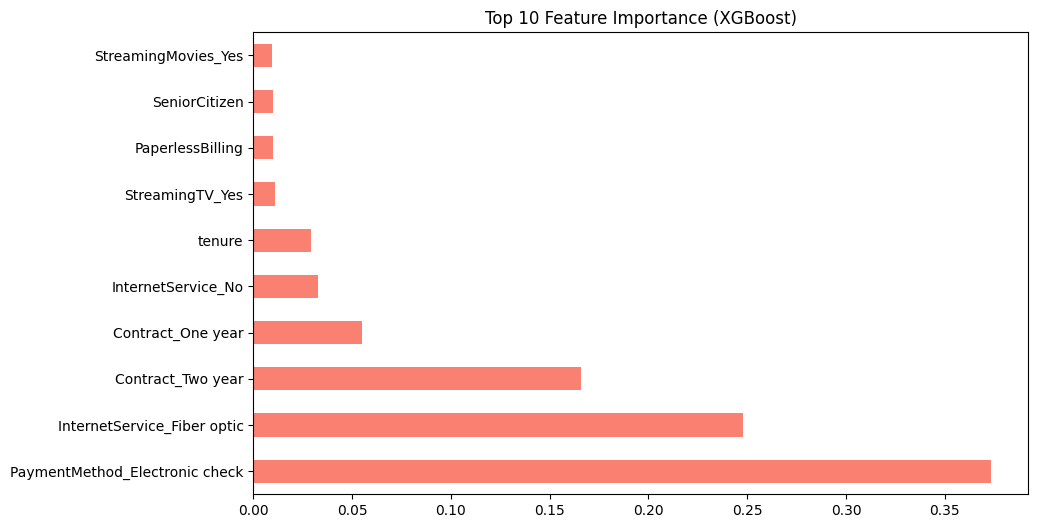

In [ ]:
# 특성 중요도
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Feature Importance (XGBoost)')
plt.show()

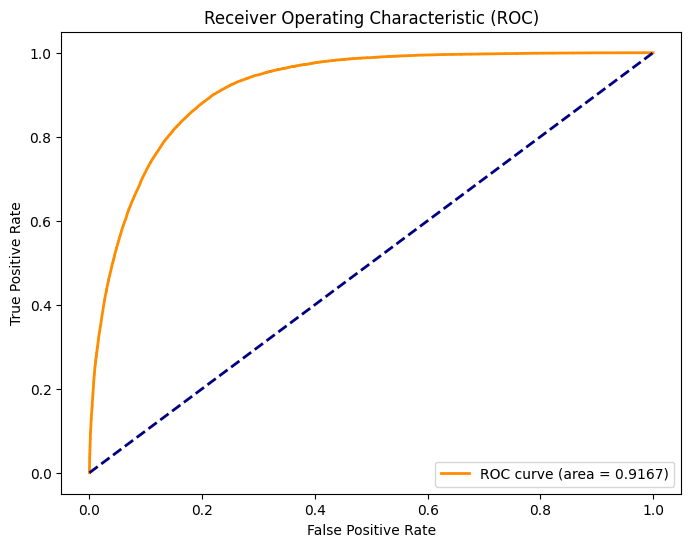

In [ ]:
# ROC CURVE
from sklearn.metrics import auc

fpr, tpr, _ = roc_curve(y_val, xgb_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

<Figure size 600x500 with 0 Axes>

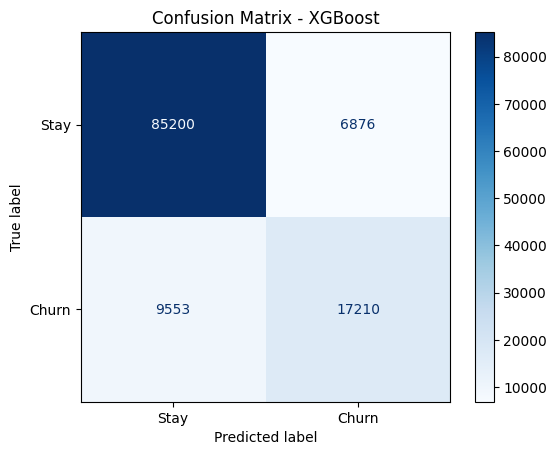

In [ ]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

xgb_preds = (xgb_probs > 0.5).astype(int)
cm = confusion_matrix(y_val, xgb_preds)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Churn']).plot(cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.show()

## **[W4] 모델 고도화**

In [ ]:
# XGBoost 튜닝
# 1. 조기 종료 콜백 (최근 5회 동안 개선 없으면 중단)
class EarlyStoppingCallback:
    def __init__(self, early_stopping_rounds: int, direction: str = "maximize"):
        self.early_stopping_rounds = early_stopping_rounds
        self._iter = 0
        self._best_score = None
        self.direction = direction

    def __call__(self, study: optuna.study.Study, trial: optuna.trial.FrozenTrial) -> None:
        current_score = trial.value
        if current_score is None: return

        if self._best_score is None:
            self._best_score = current_score
            return

        if (self.direction == "maximize" and current_score > self._best_score) or \
           (self.direction == "minimize" and current_score < self._best_score):
            self._best_score = current_score
            self._iter = 0
        else:
            self._iter += 1

        if self._iter >= self.early_stopping_rounds:
            print(f"\n[Early Stopping] {self.early_stopping_rounds}회 동안 개선이 없어 종료합니다.")
            study.stop()

def objective(trial):
    # 2. 추천 범위로 최적화 (너무 넓은 범위 축소)
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800), # 너무 많으면 과적합 위험
        'max_depth': trial.suggest_int('max_depth', 3, 7),           # 정형 데이터는 3~7이 효율적
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True), # 낮은 학습률 권장
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'random_state': 42,
        'tree_method': 'hist', # CPU 환경일 경우 hist, GPU일 경우 gpu_hist
        'n_jobs': -1           # 모든 코어 사용해서 속도 향상
    }

    model = XGBClassifier(**param)

    # 3. 속도를 위해 cv=3 유지 (ROC-AUC 기준)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='roc_auc').mean()
    return score

# 튜닝 시작
study = optuna.create_study(direction='maximize')
early_stop = EarlyStoppingCallback(early_stopping_rounds=5) # 5회 미개선 시 종료

# n_trials를 50으로 늘려도 조기 종료 덕분에 유의미한 시도만 하고 멈춥니다.
study.optimize(objective, n_trials=50, callbacks=[early_stop])

print(f"\nBest Score: {study.best_value}")
print(f"Best Params: {study.best_params}")

# 4. 시각화를 통한 범위 타당성 검토
# 어떤 파라미터가 점수에 큰 영향을 줬는지 확인
vis.plot_param_importances(study).show()

# 파라미터별로 어느 구간에서 점수가 높게 형성되었는지 확인 (Slice Plot)
vis.plot_slice(study).show()

[I 2026-03-24 00:48:32,735] A new study created in memory with name: no-name-1ba12f2c-7793-47c4-bab2-928cd9856a62
[I 2026-03-24 00:49:20,732] Trial 0 finished with value: 0.91601093061715 and parameters: {'n_estimators': 609, 'max_depth': 5, 'learning_rate': 0.048352673648382694, 'subsample': 0.7658026157855462, 'colsample_bytree': 0.8981962396455374, 'min_child_weight': 4}. Best is trial 0 with value: 0.91601093061715.
[I 2026-03-24 00:49:55,785] Trial 1 finished with value: 0.9120908768436614 and parameters: {'n_estimators': 487, 'max_depth': 3, 'learning_rate': 0.011561603392568417, 'subsample': 0.677944934482137, 'colsample_bytree': 0.7872895378222537, 'min_child_weight': 7}. Best is trial 0 with value: 0.91601093061715.
[I 2026-03-24 00:50:31,516] Trial 2 finished with value: 0.9151418298354804 and parameters: {'n_estimators': 461, 'max_depth': 4, 'learning_rate': 0.03338988063583547, 'subsample': 0.8127173095297775, 'colsample_bytree': 0.6044326047220038, 'min_child_weight': 5}. 


[Early Stopping] 5회 동안 개선이 없어 종료합니다.

Best Score: 0.91601093061715
Best Params: {'n_estimators': 609, 'max_depth': 5, 'learning_rate': 0.048352673648382694, 'subsample': 0.7658026157855462, 'colsample_bytree': 0.8981962396455374, 'min_child_weight': 4}


앙상블 모델 학습

[최종 모델 결과]
Ensemble (RF + XGB) ROC-AUC: 0.9158


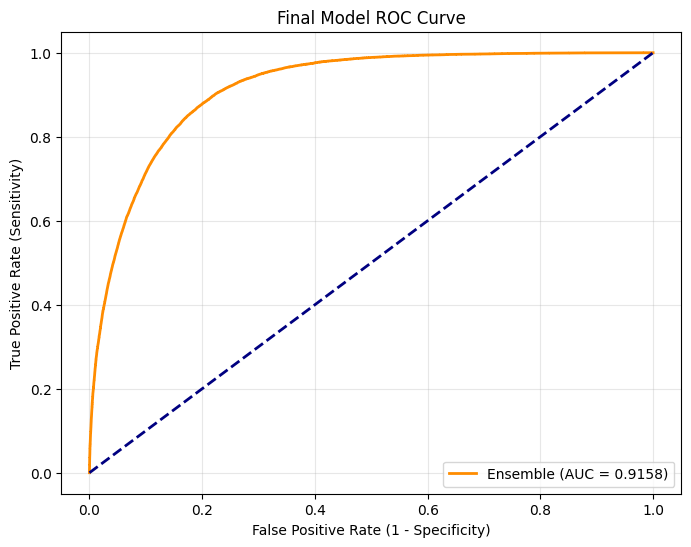

In [ ]:
# 1. Random Forest 설정
best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# 2. 방금 Optuna로 찾은 최적의 XGBoost 설정
best_xgb = XGBClassifier(
    n_estimators=599,
    max_depth=7,
    learning_rate=0.033814395447854174,
    subsample=0.8298191307811806,
    colsample_bytree=0.729610158769305,
    min_child_weight=4,
    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

# 3. Soft Voting 앙상블 생성
voting_model = VotingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    voting='soft', # 확률값 평균 방식
    n_jobs=-1
)

# 4. 모델 학습
print("앙상블 모델 학습")
voting_model.fit(X_train, y_train)

# 5. 최종 성능 확인 (ROC-AUC)
y_pred_proba = voting_model.predict_proba(X_val)[:, 1] # 검증 데이터 확률 추출
final_auc = roc_auc_score(y_val, y_pred_proba)

print(f"\n[최종 모델 결과]")
print(f"Ensemble (RF + XGB) ROC-AUC: {final_auc:.4f}")

# 6. ROC Curve 시각화 (발표 자료용)
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Ensemble (AUC = {final_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Final Model ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

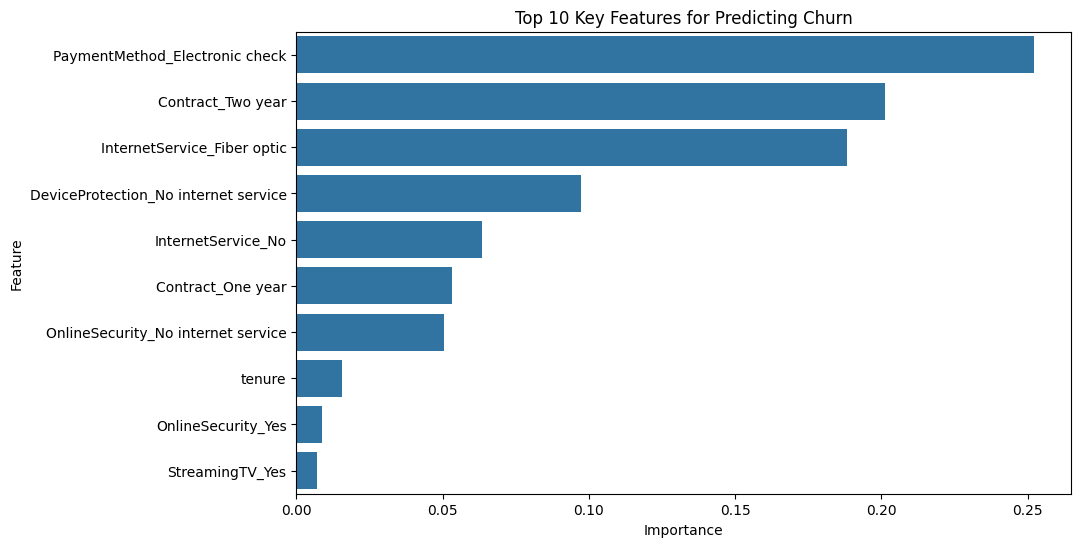

In [ ]:
# XGBoost 모델 기준 특성 중요도 추출
importances = best_xgb.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Key Features for Predicting Churn')
plt.show()

## **결과**

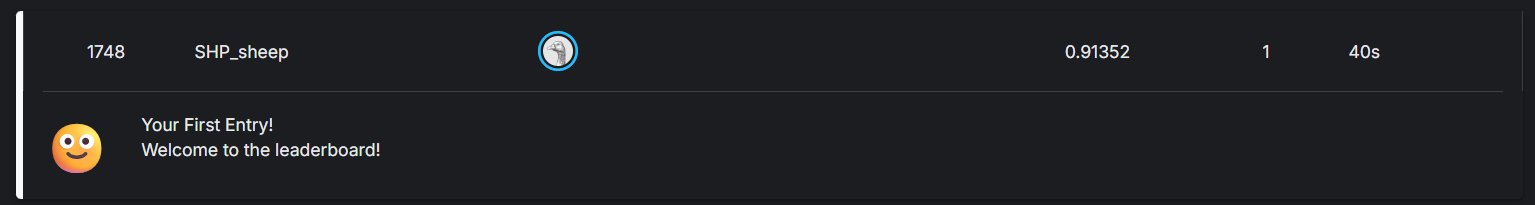

In [ ]:
# 1. 테스트 데이터 불러오기
test_df = pd.read_csv('test_proc (1).csv')

# 2. 테스트 데이터 전처리
# 주의: 2주차에 진행했던 인코딩, 결측치 처리, 스케일링 등을 동일하게 적용해야 합니다.
# 만약 전처리 함수를 만들어두셨다면 그 함수를 사용하세요.
# X_test = test_df.drop(['id'], axis=1) # id 컬럼 제외

# (예시) 범주형 변수 처리 등이 포함되어야 함
# X_test = pd.get_dummies(X_test) 등...
X_test = test_df # X_test를 test_df로 정의하여 오류 해결

# best_xgb 모델을 개별적으로 학습시킵니다.
best_xgb.fit(X_train, y_train)

# 3. 모델로 예측 (확률값 추출)
# 4주차에서 학습시킨 최적의 모델(best_xgb)을 사용합니다.
test_preds_proba = best_xgb.predict_proba(X_test)[:, 1]

# 4. 제출 양식 파일 생성
submission = pd.DataFrame({'id': test_id['id'], 'Churn': test_preds_proba})

# 5. CSV 파일로 저장
submission.to_csv('submission_V1.csv', index=False)

print("제출 파일 'submission_yang.csv'이 생성되었습니다! Kaggle에 업로드하세요.")